# CA_EQ_Shallow Shapefile Attribute Table Analysis

This notebook loads the CA_EQ_Shallow shapefile and generates visualizations of the different columns within the attribute table.

## Section 1: Import Required Libraries

Import necessary libraries including geopandas, pandas, matplotlib, and seaborn for loading and visualizing shapefiles.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load the Shapefile

Use geopandas to read the CA_EQ_Shallow shapefile and display basic information about the data structure.

In [2]:
# Set the path to the shapefile
shapefile_path = r'c:\Earthquake_correlation_shapefiles\CA_EQ_Shallow.shp'

# Load the shapefile using geopandas
gdf = gpd.read_file(shapefile_path)

# Display basic information
print("Shapefile loaded successfully!")
print(f"Total number of features: {len(gdf)}")
print(f"\nCoordinate Reference System: {gdf.crs}")
print(f"\nGeometry type: {gdf.geometry.geom_type.unique()}")
print(f"\nDataFrame shape: {gdf.shape}")

Shapefile loaded successfully!
Total number of features: 13055

Coordinate Reference System: EPSG:4326

Geometry type: ['Point']

DataFrame shape: (13055, 28)


## Section 3: Explore the Attribute Table

Display the first few rows, column names, data types, and basic statistics of the attribute table.

In [3]:
# Display first few rows
print("First 5 rows of the attribute table:")
print(gdf.head())
print("\n" + "="*80 + "\n")

First 5 rows of the attribute table:
   Join_Count  TARGET_FID       time   latitude   longitude  depth   mag  \
0           1           1 2026-04-26  34.387833 -116.161000  -0.28  1.65   
1           1           2 2026-04-25  36.523335 -121.123665  -0.65  1.19   
2           1           3 2026-04-25  38.793499 -122.762337  -0.05  1.04   
3           1           4 2026-04-24  35.424167 -120.560500  -0.36  1.19   
4           1           5 2026-04-24  32.902833 -116.944000  -0.19  1.16   

  magType  nst  gap  ...  depthError  magError magNst     status locationSo  \
0      ml   31   59  ...        0.38  0.161583     21   reviewed         ci   
1      md   10  116  ...        2.98  0.230000      8  automatic         nc   
2      md    8  113  ...        0.99  0.070000      8  automatic         nc   
3      md   18   84  ...       31.61  0.196000      8   reviewed         nc   
4      ml   24   86  ...       31.61  0.145792     11   reviewed         ci   

  magSource PTYPE    SHAPE_Leng

In [4]:
# Display column information
print("Column Names and Data Types:")
print("-" * 80)
for col in gdf.columns:
    print(f"  {col:20s} : {str(gdf[col].dtype):20s} (Non-null count: {gdf[col].notna().sum()})")
print("\n" + "="*80 + "\n")

Column Names and Data Types:
--------------------------------------------------------------------------------
  Join_Count           : int64                (Non-null count: 13055)
  TARGET_FID           : int64                (Non-null count: 13055)
  time                 : datetime64[ms]       (Non-null count: 13055)
  latitude             : float64              (Non-null count: 13055)
  longitude            : float64              (Non-null count: 13055)
  depth                : float64              (Non-null count: 13055)
  mag                  : float64              (Non-null count: 13055)
  magType              : object               (Non-null count: 13055)
  nst                  : int64                (Non-null count: 13055)
  gap                  : int64                (Non-null count: 13055)
  dmin                 : float64              (Non-null count: 13055)
  rms                  : float64              (Non-null count: 13055)
  net                  : object               (Non

In [5]:
# Display basic statistics for numerical columns
print("Basic Statistics for Numerical Columns:")
print("-" * 80)
print(gdf.describe())
print("\n" + "="*80 + "\n")

Basic Statistics for Numerical Columns:
--------------------------------------------------------------------------------
       Join_Count    TARGET_FID                        time      latitude  \
count     13055.0  13055.000000                       13055  13055.000000   
mean          1.0   6528.000000  2020-12-03 18:53:14.913000     36.173007   
min           1.0      1.000000         2016-04-27 00:00:00     32.390500   
25%           1.0   3264.500000         2018-04-19 00:00:00     34.514917   
50%           1.0   6528.000000         2020-10-19 00:00:00     35.909500   
75%           1.0   9791.500000         2023-05-31 00:00:00     37.922017   
max           1.0  13055.000000         2026-04-26 00:00:00     42.055833   
std           0.0   3768.798217                         NaN      2.146864   

          longitude         depth           mag           nst           gap  \
count  13055.000000  13055.000000  13055.000000  13055.000000  13055.000000   
mean    -119.152829     -0.

## Section 4: Visualize Numerical Columns

Create histograms, box plots, and distribution plots for all numerical columns in the attribute table.

Numerical columns found: ['Join_Count', 'TARGET_FID', 'latitude', 'longitude', 'depth', 'mag', 'nst', 'gap', 'dmin', 'rms', 'horizontal', 'depthError', 'magError', 'magNst', 'SHAPE_Leng']



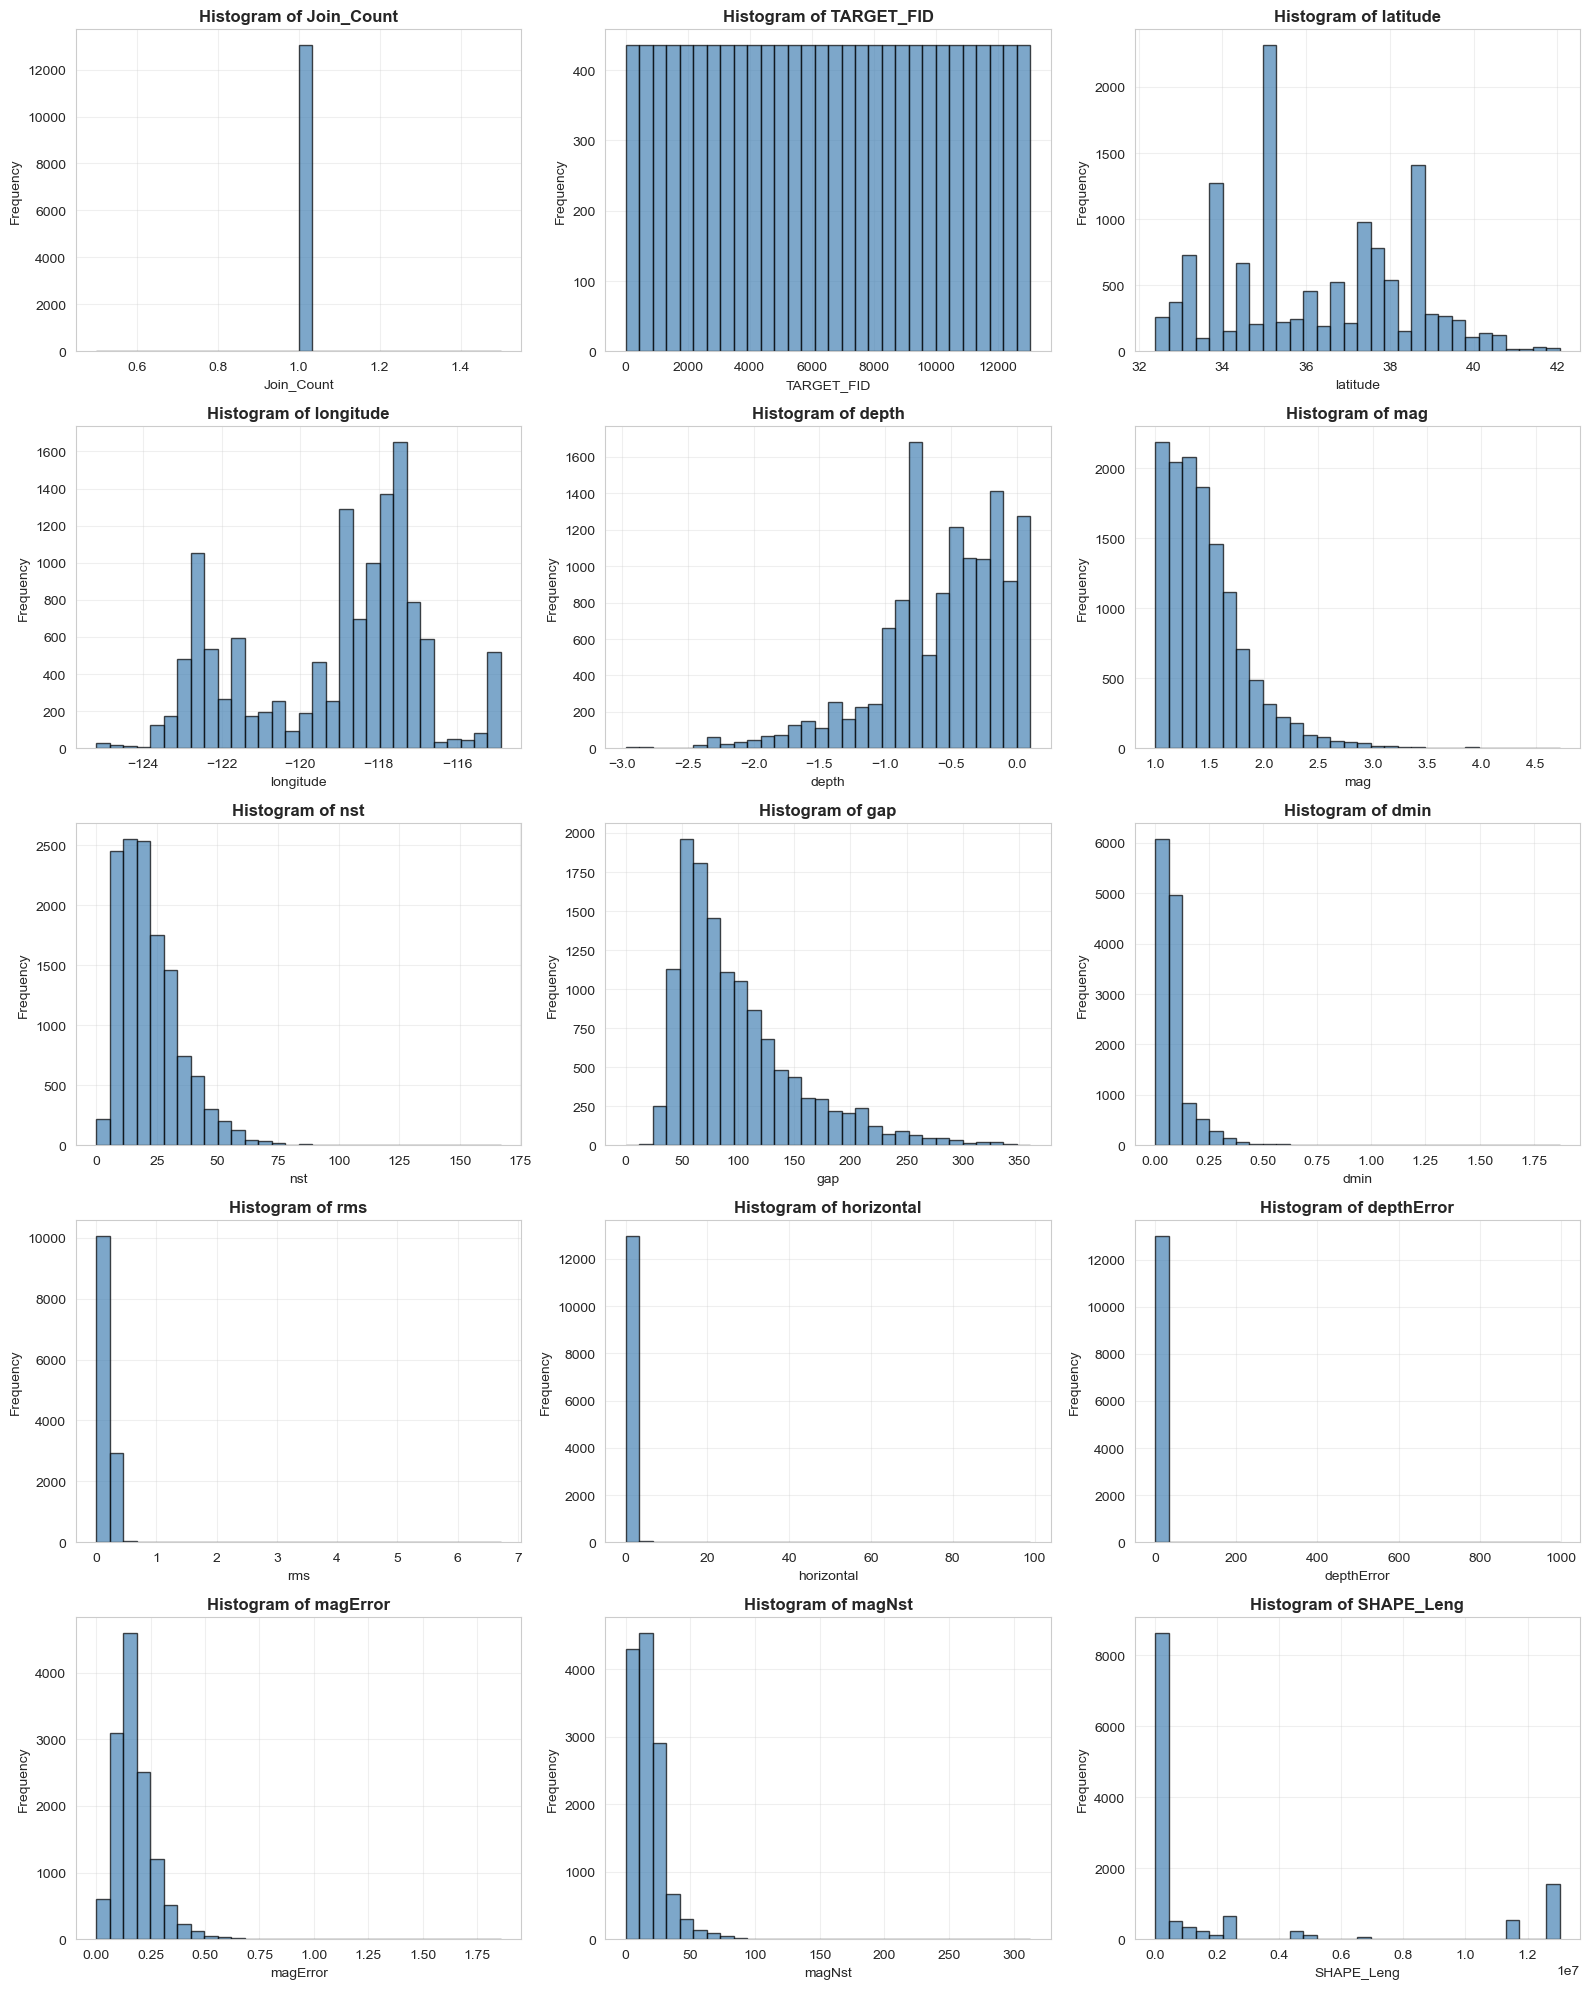

Histograms saved as 'CA_EQ_Shallow_Histograms.png'



In [6]:
# Get numerical columns (excluding geometry)
numerical_cols = gdf.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numerical columns found: {numerical_cols}\n")

# Create histograms for numerical columns
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))  # Max 3 columns per row
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].hist(gdf[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(r'c:\Earthquake_correlation_shapefiles\Code\CA_EQ_Shallow_Histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Histograms saved as 'CA_EQ_Shallow_Histograms.png'\n")

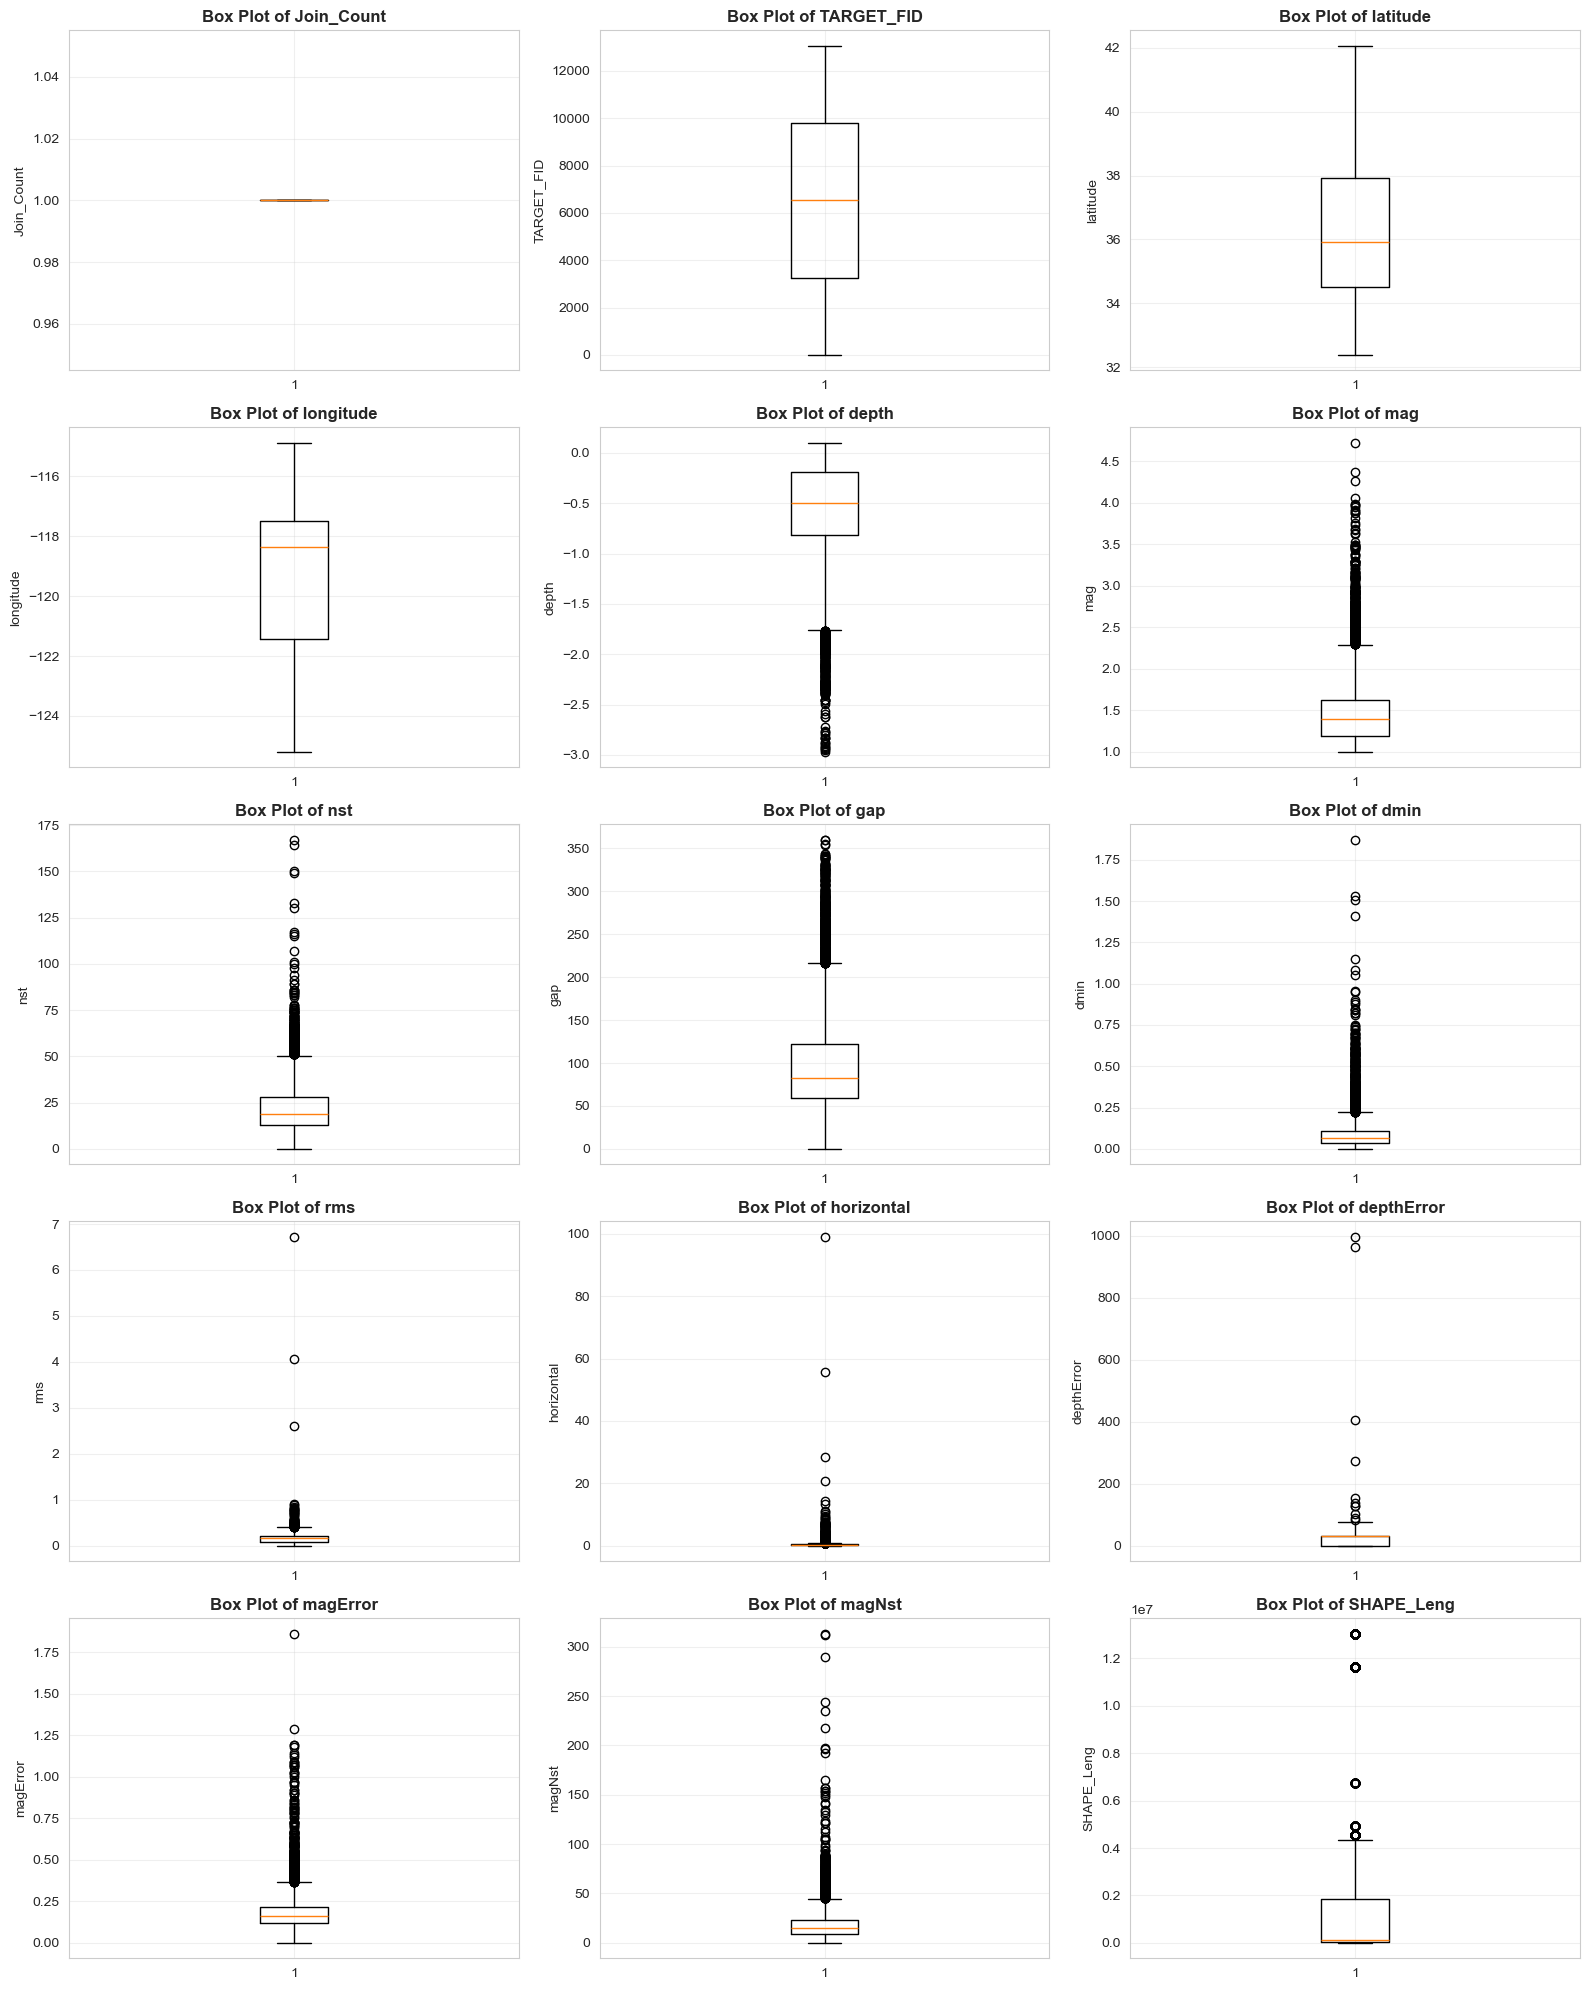

Box plots saved as 'CA_EQ_Shallow_BoxPlots.png'



In [7]:
# Create box plots for numerical columns
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))  # Max 3 columns per row
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        axes[idx].boxplot(gdf[col].dropna())
        axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(r'c:\Earthquake_correlation_shapefiles\Code\CA_EQ_Shallow_BoxPlots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Box plots saved as 'CA_EQ_Shallow_BoxPlots.png'\n")

## Section 5: Visualize Categorical Columns

Create bar charts and count plots for categorical columns to show the distribution of values.

Categorical columns found: ['magType', 'net', 'id', 'place', 'type', 'status', 'locationSo', 'magSource', 'PTYPE', 'Rock_Type']



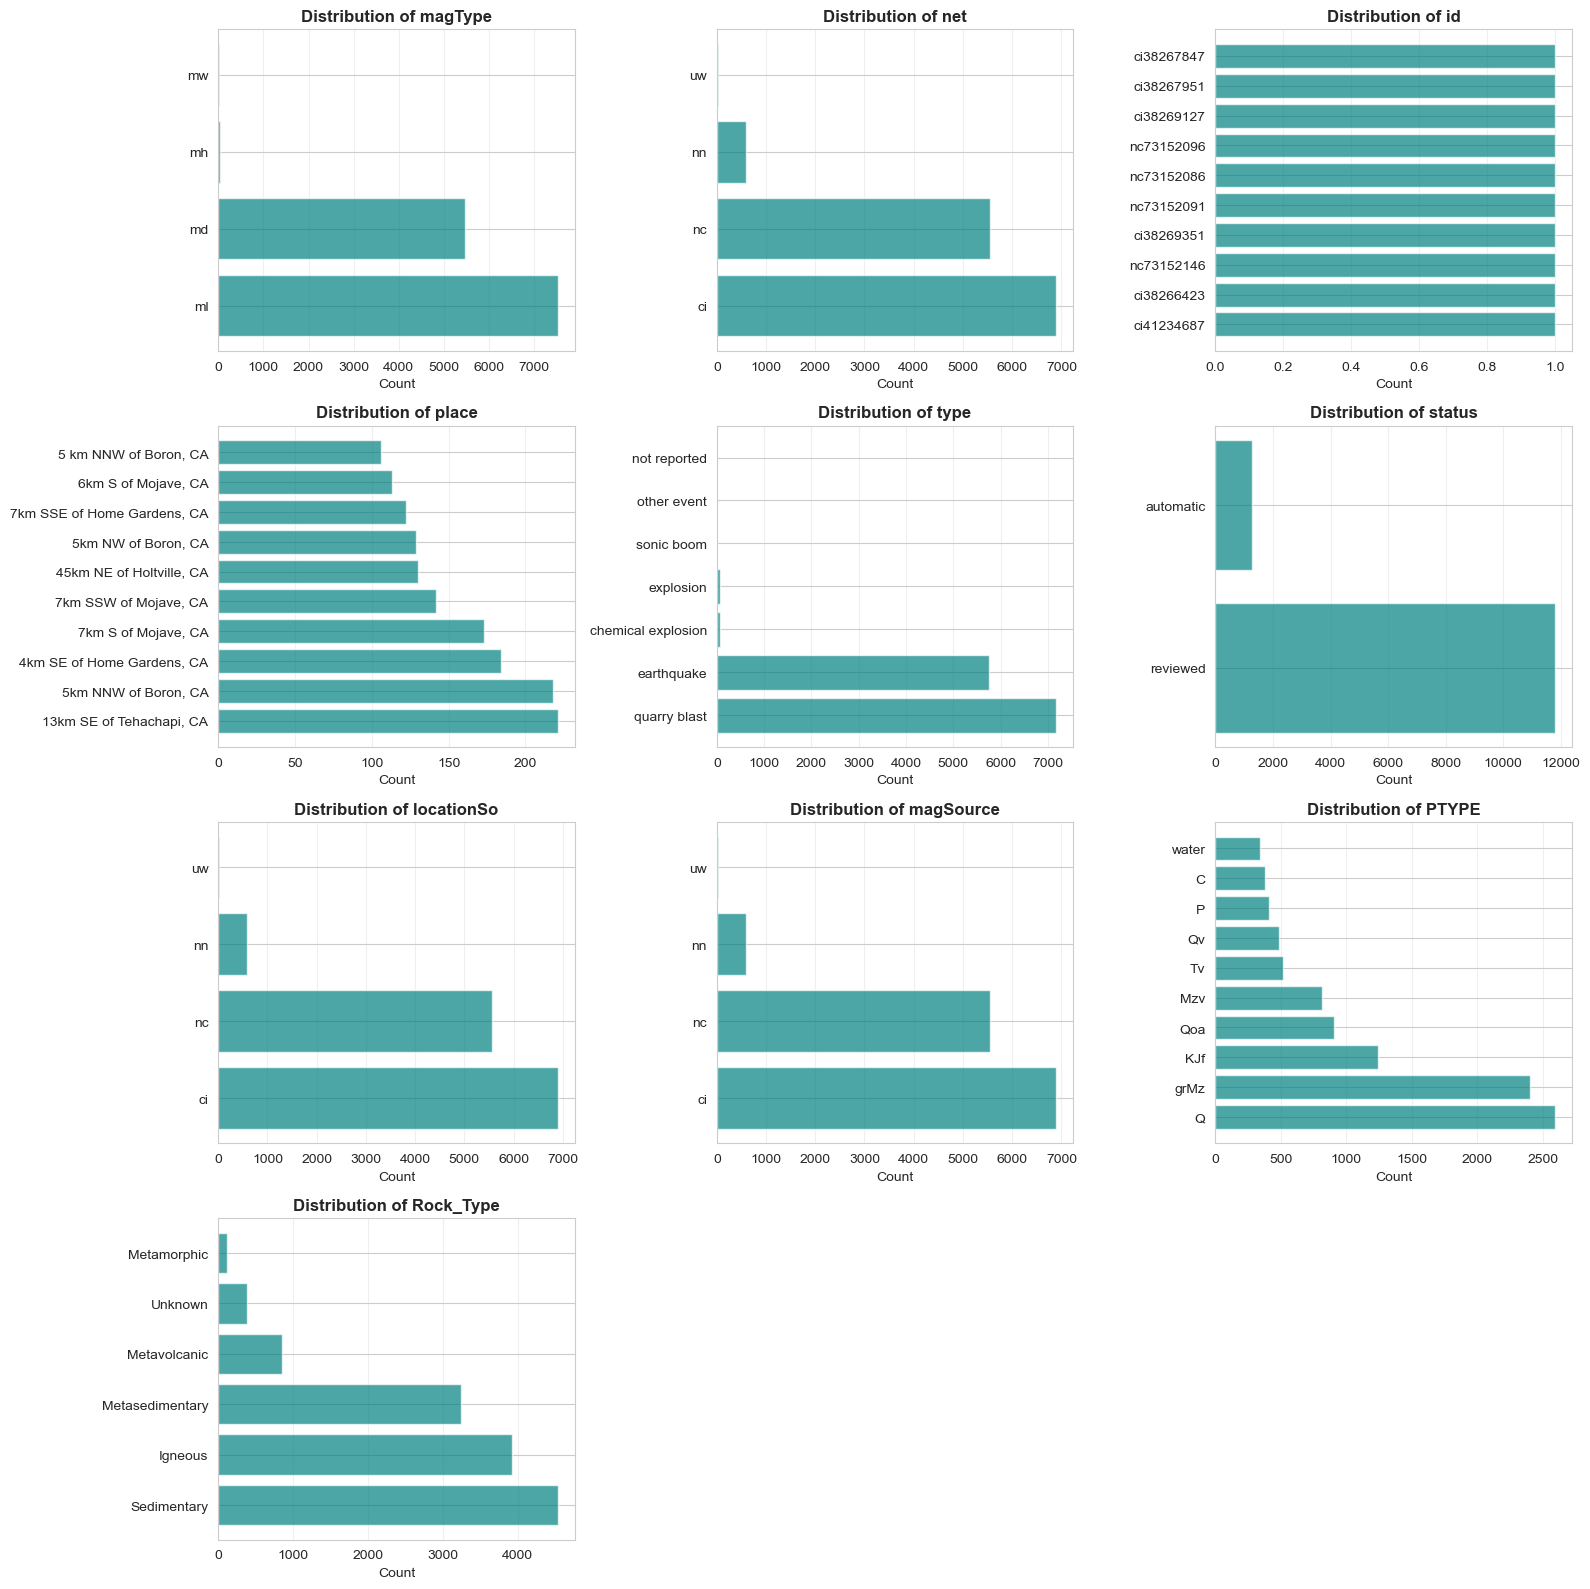

Categorical charts saved as 'CA_EQ_Shallow_CategoricalCharts.png'



In [8]:
# Get categorical columns (excluding geometry)
categorical_cols = gdf.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'geometry']

print(f"Categorical columns found: {categorical_cols}\n")

# Create bar charts for categorical columns (with limited categories)
if len(categorical_cols) > 0:
    n_cols = min(3, len(categorical_cols))  # Max 3 columns per row
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        value_counts = gdf[col].value_counts().head(10)  # Top 10 values
        axes[idx].barh(range(len(value_counts)), value_counts.values, color='teal', alpha=0.7)
        axes[idx].set_yticks(range(len(value_counts)))
        axes[idx].set_yticklabels(value_counts.index)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].grid(True, alpha=0.3, axis='x')
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(r'c:\Earthquake_correlation_shapefiles\Code\CA_EQ_Shallow_CategoricalCharts.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Categorical charts saved as 'CA_EQ_Shallow_CategoricalCharts.png'\n")

## Section 6: Create Summary Statistics and Column Overview

Generate a comprehensive summary statistics table and create a visual summary of all columns.

In [9]:
# Create comprehensive attribute table summary
attribute_summary = []

for col in gdf.columns:
    if col != 'geometry':
        col_data = gdf[col]
        summary = {
            'Column Name': col,
            'Data Type': str(col_data.dtype),
            'Non-Null Count': col_data.notna().sum(),
            'Null Count': col_data.isna().sum(),
            'Unique Values': col_data.nunique(),
        }
        
        # Add statistics based on data type
        if pd.api.types.is_numeric_dtype(col_data):
            summary['Min'] = col_data.min()
            summary['Max'] = col_data.max()
            summary['Mean'] = col_data.mean()
            summary['Std'] = col_data.std()
        else:
            summary['Sample Value'] = str(col_data.dropna().iloc[0] if len(col_data.dropna()) > 0 else 'N/A')
        
        attribute_summary.append(summary)

summary_df = pd.DataFrame(attribute_summary)

print("ATTRIBUTE TABLE SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)

ATTRIBUTE TABLE SUMMARY
Column Name      Data Type  Non-Null Count  Null Count  Unique Values         Min           Max          Mean          Std                      Sample Value
 Join_Count          int64           13055           0              1    1.000000  1.000000e+00  1.000000e+00 0.000000e+00                               NaN
 TARGET_FID          int64           13055           0          13055    1.000000  1.305500e+04  6.528000e+03 3.768798e+03                               NaN
       time datetime64[ms]           13055           0           3240         NaN           NaN           NaN          NaN               2026-04-26 00:00:00
   latitude        float64           13055           0           7811   32.390500  4.205583e+01  3.617301e+01 2.146864e+00                               NaN
  longitude        float64           13055           0           8057 -125.199000 -1.148785e+02 -1.191528e+02 2.271394e+00                               NaN
      depth        float64        

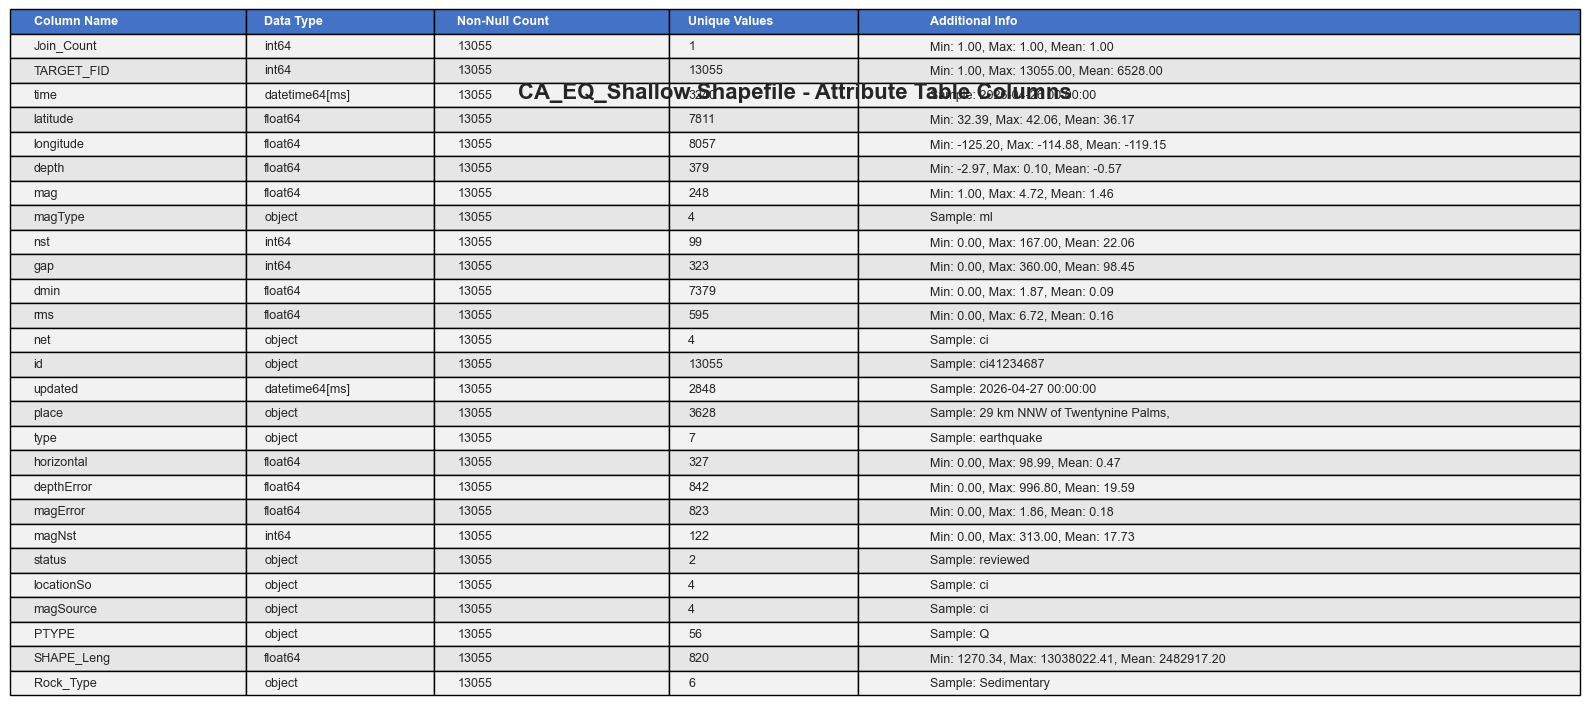

Attribute table visualization saved as 'CA_EQ_Shallow_Attribute_Table.png'



In [10]:
# Create a visual table of attribute columns
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Prepare table data - select relevant columns
table_data = []
table_data.append(['Column Name', 'Data Type', 'Non-Null Count', 'Unique Values', 'Additional Info'])

for col in gdf.columns:
    if col != 'geometry':
        col_data = gdf[col]
        col_type = str(col_data.dtype)
        non_null = col_data.notna().sum()
        unique = col_data.nunique()
        
        if pd.api.types.is_numeric_dtype(col_data):
            additional = f"Min: {col_data.min():.2f}, Max: {col_data.max():.2f}, Mean: {col_data.mean():.2f}"
        else:
            additional = f"Sample: {str(col_data.dropna().iloc[0] if len(col_data.dropna()) > 0 else 'N/A')[:30]}"
        
        table_data.append([col, col_type, str(non_null), str(unique), additional])

# Create table
table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                colWidths=[0.15, 0.12, 0.15, 0.12, 0.46])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style alternating rows
for i in range(1, len(table_data)):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('#F2F2F2')

plt.title('CA_EQ_Shallow Shapefile - Attribute Table Columns', 
         fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(r'c:\Earthquake_correlation_shapefiles\Code\CA_EQ_Shallow_Attribute_Table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Attribute table visualization saved as 'CA_EQ_Shallow_Attribute_Table.png'\n")